- yfinance 설치

In [1]:
!pip install yfinance

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 43.6 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15703 sha256=2d6758623fb516e56a819d91af08aff8ab0161d276f305318d4e219b1fb47bc4
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\42\d6\84\bf57a755f4569494cd00de4bb46ef064874823f4d19c82e960
Successfully built multitasking

   ---------------- ----------------------- 2/5 [websockets]
   -------------------------------- ------- 4/5 [yfinance]
   ---------------------------------------- 5/5 [yfinance]



  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334


- 라이브러리 임포트

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import yfinance as yf
import koreanize_matplotlib
import matplotlib.ticker as mtick

- 애플의 1년치 데이터 다운로드 후 일부데이터 출력, 데이터 크기 출력
- 야후파이낸스에서 지정한 티커(종목코드) 기준
- 애플의 티커는 AAPL

In [104]:
# 애플(AAPL)의 1년치 데이터 다운로드
# (삼성전자를 보고 싶다면 '005930.KS'를 넣으면 됩니다)
df = yf.download('000660.KS', period='1y')

# 데이터가 잘 왔는지 확인 (날짜, 시가, 고가, 저가, 종가, 거래량 등이 보입니다)
df.columns
# 시작:25-03-04, 인덱스:251개, 컬럼:멀티5개, 필요한것은 종 

[*********************100%***********************]  1 of 1 completed


MultiIndex([( 'Close', '000660.KS'),
            (  'High', '000660.KS'),
            (   'Low', '000660.KS'),
            (  'Open', '000660.KS'),
            ('Volume', '000660.KS')],
           names=['Price', 'Ticker'])

- 컬럼명과 인덱스 출력

In [105]:
df.columns

MultiIndex([( 'Close', '000660.KS'),
            (  'High', '000660.KS'),
            (   'Low', '000660.KS'),
            (  'Open', '000660.KS'),
            ('Volume', '000660.KS')],
           names=['Price', 'Ticker'])

In [106]:
df.index

DatetimeIndex(['2025-03-04', '2025-03-05', '2025-03-06', '2025-03-07',
               '2025-03-10', '2025-03-11', '2025-03-12', '2025-03-13',
               '2025-03-14', '2025-03-17',
               ...
               '2026-02-13', '2026-02-19', '2026-02-20', '2026-02-23',
               '2026-02-24', '2026-02-25', '2026-02-26', '2026-02-27',
               '2026-03-03', '2026-03-04'],
              dtype='datetime64[ns]', name='Date', length=243, freq=None)

In [92]:
df['Close']

Ticker,005930.KS
Date,
2025-03-04,53349.304688
2025-03-05,52859.863281
2025-03-06,53153.527344
2025-03-07,52566.195312
2025-03-10,52566.195312
...,...
2026-02-25,203500.000000
2026-02-26,218000.000000
2026-02-27,216500.000000


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 243 entries, 2025-03-04 to 2026-03-04
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Close, 000660.KS)   243 non-null    float64
 1   (High, 000660.KS)    243 non-null    float64
 2   (Low, 000660.KS)     243 non-null    float64
 3   (Open, 000660.KS)    243 non-null    float64
 4   (Volume, 000660.KS)  243 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.4 KB


- 결측치 확인
- 결측치 채우기( 앞의 데이터로 채우기 : ffill , 뒤의 데이터로 채우기 : bfill )

In [108]:
# 빈칸(결측치)이 있는지 확인
df.isnull().sum()

# 만약 빈칸이 있다면, 바로 전날의 가격으로 채워넣기 (ffill: forward fill)
df = df.ffill() #데이터프레임의 제일 첫번째 데이터가 없다면 함수실행 불가
df = df.bfill()

# 데이터 정보 최종 확인 (날짜 타입, 숫자 타입 등이 맞는지 점검)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 243 entries, 2025-03-04 to 2026-03-04
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Close, 000660.KS)   243 non-null    float64
 1   (High, 000660.KS)    243 non-null    float64
 2   (Low, 000660.KS)     243 non-null    float64
 3   (Open, 000660.KS)    243 non-null    float64
 4   (Volume, 000660.KS)  243 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.4 KB


- 종가를 기준으로 이동평균 계산
- 이동평균은 판다스의 rolling(개수).mean() 함수 사용

In [109]:
# 종가(Close)를 기준으로 이동평균 계산
df['Close'].mean()

Ticker
000660.KS    411460.037166
dtype: float64

In [110]:
# 20일 이동평균선 (창문을 20개씩 옆으로 밀며 평균 구하기)
df['MA20']=df[('Close','000660.KS')].rolling(window=20).mean()
df['MA20']

Date
2025-03-04              NaN
2025-03-05              NaN
2025-03-06              NaN
2025-03-07              NaN
2025-03-10              NaN
                  ...      
2026-02-25    882022.450000
2026-02-26    900240.231250
2026-02-27    913363.906250
2026-03-03    918341.356250
2026-03-04    920870.646875
Name: MA20, Length: 243, dtype: float64

In [111]:
# 60일 이동평균선

# 계산된 결과 확인 (앞부분 20일은 데이터가 부족해 NaN으로 나옵니다)
df['MA60']=df[('Close','000660.KS')].rolling(window=60).mean()
df['MA60']

Date
2025-03-04              NaN
2025-03-05              NaN
2025-03-06              NaN
2025-03-07              NaN
2025-03-10              NaN
                  ...      
2026-02-25    716854.313542
2026-02-26    726459.970833
2026-02-27    735093.336458
2026-03-03    741926.272917
2026-03-04    748142.788542
Name: MA60, Length: 243, dtype: float64

- 시각화
- 실제 주가와 20일 이동평균선, 60일 이동평균선 출력
- 범례와 격자 출력

In [4]:
 # 그래프 크기 키우기

# 1. 실제 주가 (얇은 선)


# 2. 20일 이동평균선 (주황색, 단기 추세)


# 3. 60일 이동평균선 (파란색, 중기 추세)


# 그래프 꾸미기


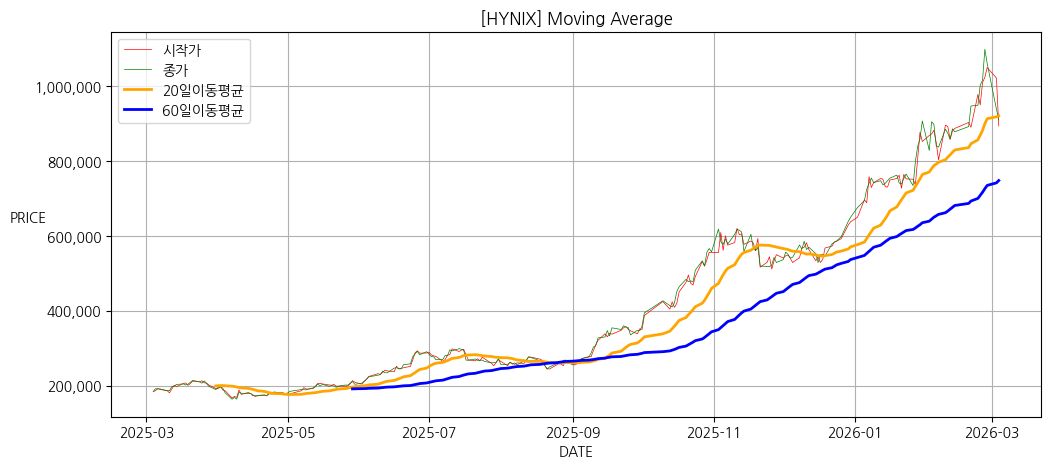

In [114]:
plt.figure(figsize=(12,5))

plt.plot(df['Open'], label='시작가', color='red', lw=0.5)
plt.plot(df['Close'], label='종가', color='green', lw=0.5)
plt.plot(df['MA20'], label='20일이동평균', color='orange', lw=2)
plt.plot(df['MA60'], label='60일이동평균', color='blue', lw=2)

plt.title('[HYNIX] Moving Average')
plt.xlabel('DATE')
plt.ylabel('PRICE', rotation=0)


plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)
plt.legend()
plt.grid(True)
plt.savefig('HYNIX_Moving Average.png')
plt.show()